In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Reading the Evaluation data by Pathologist

In [7]:
evaluator_ids = ['evaluator1', 'evaluator2', 'evaluator4', 'evaluator5']
eval_data_correct_answers = []
for evaluator_id in evaluator_ids:
    eval_data_path = f"output/{evaluator_id}/pathopen_correct_answer_eval_data.pkl"
    eval_data = pd.read_pickle(eval_data_path)
    eval_data_correct_answers.append(eval_data)

eval_data_correct_answers[0].head()

Total  Level 2  Level 1  Level 0  \
Open-Ended  Knowledge Interpretation     92       83        8        1   
            Visual Grounding             92       82        9        1   
MCQ         Knowledge Interpretation     46       43        1        2   
            Visual Grounding             46       43        1        2   
Close-Ended Visual Grounding             46       46        0        0   

                                      Level -1  
Open-Ended  Knowledge Interpretation         0  
            Visual Grounding                 0  
MCQ         Knowledge Interpretation         0  
            Visual Grounding                 0  
Close-Ended Visual Grounding                 0

In [8]:
eval_data_correct_answers[1]

Level 2  Level 1  Level 0  Level -1
Open-Ended  Knowledge Interpretation       87        3        0         0
            Visual Grounding               88        2        0         0
MCQ         Knowledge Interpretation       46        0        0         0
            Visual Grounding               42        3        1         0
Close-Ended Visual Grounding               43        2        1         0

In [4]:
eval_data_correct_answers[0] + eval_data_correct_answers[1]

Level 2  Level 1  Level 0  Level -1
Open-Ended  Knowledge Interpretation      170       11        1         0
            Visual Grounding              170       11        1         0
MCQ         Knowledge Interpretation       89        1        2         0
            Visual Grounding               85        4        3         0
Close-Ended Visual Grounding               89        2        1         0

Creating the directory structure to save Graphs and Output for Each Evaluator

In [105]:
output_data_path = f"output/{evaluator_id}"
os.makedirs(output_data_path, exist_ok=True)

Renaming some columns

In [106]:
eval_data = eval_data.rename(columns={'Evaluation OE_Correct_Answer_1\n(Benchmark 1)': 'OE_Correct_Answer_1_Know_Inter',
                                        'Unnamed: 6': 'OE_Correct_Answer_1_Vis_Ground',
                                        'Evaluation OE_Wrong_Answer_1\n(Benchmark 2)': 'OE_Wrong_Answer_1_Err_Prox',
                                        'Unnamed: 9': 'OE_Wrong_Answer_1_Vis_Ground',
                                        'Evaluation OE_Correct_Answer_2\n(Benchmark 1)': 'OE_Correct_Answer_2_Know_Inter',
                                        'Unnamed: 13': 'OE_Correct_Answer_2_Vis_Ground',
                                        'Evaluation OE_Wrong_Answer_2\n(Benchmark 2)': 'OE_Wrong_Answer_2_Err_Prox',
                                        'Unnamed: 16': 'OE_Wrong_Answer_2_Vis_Ground',
                                        'Evaluation MCQ_OE_Correct_Answer\n(Benchmark 1)': 'MCQ_OE_Correct_Answer_Know_Inter',
                                        'Unnamed: 20': 'MCQ_OE_Correct_Answer_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_1\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_1_Err_Prox',
                                        'Unnamed: 23': 'MCQ_OE_Wrong_Answer_1_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_2\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_2_Err_Prox',
                                        'Unnamed: 26': 'MCQ_OE_Wrong_Answer_2_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_3\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_3_Err_Prox',
                                        'Unnamed: 29': 'MCQ_OE_Wrong_Answer_3_Vis_Ground',
                                        'Evaluation MCQ_OE_Wrong_Answer_4\n(Benchmark 2)': 'MCQ_OE_Wrong_Answer_4_Err_Prox',
                                        'Unnamed: 32': 'MCQ_OE_Wrong_Answer_4_Vis_Ground',
                                        'Evaluation CE_Correct_Answer\n(Benchmark 3)': 'CE_Correct_Answer_Vis_Ground',
                                        })

eval_data = eval_data.drop(index=0) #dropping the first row which contains the benchmark names
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,OE_Correct_Answer_1_Know_Inter,OE_Correct_Answer_1_Vis_Ground,OE_Wrong_Answer_1,OE_Wrong_Answer_1_Err_Prox,OE_Wrong_Answer_1_Vis_Ground,...,MCQ_OE_Wrong_Answer_2_Vis_Ground,MCQ_OE_Wrong_Answer_3,MCQ_OE_Wrong_Answer_3_Err_Prox,MCQ_OE_Wrong_Answer_3_Vis_Ground,MCQ_OE_Wrong_Answer_4,MCQ_OE_Wrong_Answer_4_Err_Prox,MCQ_OE_Wrong_Answer_4_Vis_Ground,CE_Question,CE_Correct_Answer,CE_Correct_Answer_Vis_Ground
1,151.0,img_pathopen_151_02,https://drive.google.com/open?id=1x33SWoWd0_Kj...,What is the organ and likely diagnosis from th...,"The image shows kidney cortex, as evidenced by...",0,0,"The image shows kidney cortex, as evidenced by...",0,0,...,1,This is end stage renal disease caused by muta...,0,0,This is end stage renal disease caused by muta...,0,0,Does the image from the kidney show hemorrhagi...,No,2
2,64.0,img_pathopen_64_01,https://drive.google.com/open?id=1qiBYBEmm9TXi...,Considering this is 14 year old girl with seve...,There is a dense perivascular predominantly ly...,2,2,There is a dense perivascular predominantly ly...,0,0,...,NaN,Glial cells with atypical nuclear cells,NaN,NaN,Tumor cells with embryonal features,NaN,NaN,Is this a tumor?,No,NaN
3,55.0,img_pathopen_55_01,https://drive.google.com/open?id=1tbuSPy8fibAG...,What are the cytologic features of this brain ...,The cells have an embryonal appearance charact...,2,2,NaN,NaN,NaN,...,0,Atypical teratoid/rhabdoid tumor,0,0,Ependymoma,0,0,Is this a low-grade tumor?,No,2
4,108.0,img_pathopen_108_01,https://drive.google.com/open?id=1v0-WTGvwL1hk...,How would you describe the abnormal tumor cell...,There is an epithelial tumor with gland format...,2,2,There is an adipocytic tumor with an infiltrat...,0,0,...,0,Proliferative fibrocystic changes,0,0,Sclerosing adenosis,0,0,Does this tumor have a circumscribed border?,No,2
5,51.0,img_pathopen_51_01,https://drive.google.com/open?id=1PQtZFlaL7ACY...,This is a large esophageal mass in a 65 year o...,This is a spindle cell neoplasm with prominent...,2,0,NaN,NaN,NaN,...,2,Adenocarcinoma,2,2,Inflammatory pseudotumor,2,2,Is this a high grade neoplasm?\n,Yes,2


Converting all the evaluation columns from Str to Int

In [107]:
eval_data = eval_data.astype({'OE_Correct_Answer_1_Know_Inter': 'float',
                                'OE_Correct_Answer_1_Vis_Ground': 'float',
                                'OE_Wrong_Answer_1_Err_Prox': 'float',
                                'OE_Wrong_Answer_1_Vis_Ground': 'float',
                                'OE_Correct_Answer_2_Know_Inter': 'float',
                                'OE_Correct_Answer_2_Vis_Ground': 'float',
                                'OE_Wrong_Answer_2_Err_Prox': 'float',
                                'OE_Wrong_Answer_2_Vis_Ground': 'float',
                                'MCQ_OE_Correct_Answer_Know_Inter': 'float',
                                'MCQ_OE_Correct_Answer_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_1_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_1_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_2_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_2_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_3_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_3_Vis_Ground': 'float',
                                'MCQ_OE_Wrong_Answer_4_Err_Prox': 'float',
                                'MCQ_OE_Wrong_Answer_4_Vis_Ground': 'float',
                                'CE_Correct_Answer_Vis_Ground': 'float',})

eval_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 1 to 47
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CASE_ID                           47 non-null     float64
 1   Image_ID                          47 non-null     str    
 2   Image_URL                         47 non-null     str    
 3   OE_Question_1                     47 non-null     str    
 4   OE_Correct_Answer_1               47 non-null     str    
 5   OE_Correct_Answer_1_Know_Inter    47 non-null     float64
 6   OE_Correct_Answer_1_Vis_Ground    47 non-null     float64
 7   OE_Wrong_Answer_1                 38 non-null     str    
 8   OE_Wrong_Answer_1_Err_Prox        38 non-null     float64
 9   OE_Wrong_Answer_1_Vis_Ground      38 non-null     float64
 10  OE_Question_2                     46 non-null     str    
 11  OE_Correct_Answer_2               46 non-null     str    
 12  OE_Correct_Answer_2_K

Finding Missing Evaluations or Wrong Evaluations

In [108]:
OE_Correct_Answer_1_Know_Inter_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Correct_Answer_1'].isnull()) & ((eval_data['OE_Correct_Answer_1_Know_Inter'].isnull()) | (~eval_data['OE_Correct_Answer_1_Know_Inter'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_1_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Correct_Answer_1'].isnull()) & ((eval_data['OE_Correct_Answer_1_Vis_Ground'].isnull()) | (~eval_data['OE_Correct_Answer_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_1_Err_Prox_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Wrong_Answer_1'].isnull()) & ((eval_data['OE_Wrong_Answer_1_Err_Prox'].isnull()) | (~eval_data['OE_Wrong_Answer_1_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_1_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_1'].isnull()) & (~eval_data['OE_Wrong_Answer_1'].isnull()) & ((eval_data['OE_Wrong_Answer_1_Vis_Ground'].isnull()) | (~eval_data['OE_Wrong_Answer_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Know_Inter_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Correct_Answer_2'].isnull()) & ((eval_data['OE_Correct_Answer_2_Know_Inter'].isnull()) | (~eval_data['OE_Correct_Answer_2_Know_Inter'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Correct_Answer_2'].isnull()) & ((eval_data['OE_Correct_Answer_2_Vis_Ground'].isnull()) | (~eval_data['OE_Correct_Answer_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_2_Err_Prox_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Wrong_Answer_2'].isnull()) & ((eval_data['OE_Wrong_Answer_2_Err_Prox'].isnull()) | (~eval_data['OE_Wrong_Answer_2_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Wrong_Answer_2_Vis_Ground_Missing = eval_data[(~eval_data['OE_Question_2'].isnull()) & (~eval_data['OE_Wrong_Answer_2'].isnull()) & ((eval_data['OE_Wrong_Answer_2_Vis_Ground'].isnull()) | (~eval_data['OE_Wrong_Answer_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Correct_Answer_Know_Inter_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Correct_Answer'].isnull()) & ((eval_data['MCQ_OE_Correct_Answer_Know_Inter'].isnull()) | (~eval_data['MCQ_OE_Correct_Answer_Know_Inter'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Correct_Answer_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Correct_Answer'].isnull()) & ((eval_data['MCQ_OE_Correct_Answer_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Correct_Answer_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_1_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_1'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_1_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_1_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_1'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_1_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_2_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_2'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_2_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_2_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_2'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_2_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_3_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_3'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_3_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_3_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_3'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_3_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_3_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_4_Err_Prox_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_4'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_4_Err_Prox'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_4_Err_Prox'].isin([-1,0,1,2])))]['Image_ID'].to_list()
MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing = eval_data[(~eval_data['MCQ_OE_Question'].isnull()) & (~eval_data['MCQ_OE_Wrong_Answer_4'].isnull()) & ((eval_data['MCQ_OE_Wrong_Answer_4_Vis_Ground'].isnull()) | (~eval_data['MCQ_OE_Wrong_Answer_4_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
CE_Correct_Answer_Vis_Ground_Missing = eval_data[(~eval_data['CE_Question'].isnull()) & (~eval_data['CE_Correct_Answer'].isnull()) & ((eval_data['CE_Correct_Answer_Vis_Ground'].isnull()) | (~eval_data['CE_Correct_Answer_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()

print(f"OE_Correct_Answer_1_Know_Inter_Missing: {OE_Correct_Answer_1_Know_Inter_Missing}")
print(f"OE_Correct_Answer_1_Vis_Ground_Missing: {OE_Correct_Answer_1_Vis_Ground_Missing}")
print(f"OE_Wrong_Answer_1_Err_Prox_Missing: {OE_Wrong_Answer_1_Err_Prox_Missing}")
print(f"OE_Wrong_Answer_1_Vis_Ground_Missing: {OE_Wrong_Answer_1_Vis_Ground_Missing}")
print(f"OE_Correct_Answer_2_Know_Inter_Missing: {OE_Correct_Answer_2_Know_Inter_Missing}")
print(f"OE_Correct_Answer_2_Vis_Ground_Missing: {OE_Correct_Answer_2_Vis_Ground_Missing}")
print(f"OE_Wrong_Answer_2_Err_Prox_Missing: {OE_Wrong_Answer_2_Err_Prox_Missing}")
print(f"OE_Wrong_Answer_2_Vis_Ground_Missing: {OE_Wrong_Answer_2_Vis_Ground_Missing}")
print(f"MCQ_OE_Correct_Answer_Know_Inter_Missing: {MCQ_OE_Correct_Answer_Know_Inter_Missing}")
print(f"MCQ_OE_Correct_Answer_Vis_Ground_Missing: {MCQ_OE_Correct_Answer_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_1_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_1_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_2_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_2_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_3_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_3_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing}")
print(f"MCQ_OE_Wrong_Answer_4_Err_Prox_Missing: {MCQ_OE_Wrong_Answer_4_Err_Prox_Missing}")
print(f"MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing: {MCQ_OE_Wrong_Answer_4_Vis_Ground_Missing}")
print(f"CE_Correct_Answer_Vis_Ground_Missing: {CE_Correct_Answer_Vis_Ground_Missing}")

OE_Correct_Answer_1_Know_Inter_Missing: []
OE_Correct_Answer_1_Vis_Ground_Missing: []
OE_Wrong_Answer_1_Err_Prox_Missing: []
OE_Wrong_Answer_1_Vis_Ground_Missing: []
OE_Correct_Answer_2_Know_Inter_Missing: ['img_pathopen_64_01']
OE_Correct_Answer_2_Vis_Ground_Missing: ['img_pathopen_64_01']
OE_Wrong_Answer_2_Err_Prox_Missing: ['img_pathopen_64_01']
OE_Wrong_Answer_2_Vis_Ground_Missing: ['img_pathopen_64_01']
MCQ_OE_Correct_Answer_Know_Inter_Missing: ['img_pathopen_64_01']
MCQ_OE_Correct_Answer_Vis_Ground_Missing: ['img_pathopen_64_01']
MCQ_OE_Wrong_Answer_1_Err_Prox_Missing: ['img_pathopen_64_01']
MCQ_OE_Wrong_Answer_1_Vis_Ground_Missing: ['img_pathopen_64_01']
MCQ_OE_Wrong_Answer_2_Err_Prox_Missing: ['img_pathopen_64_01']
MCQ_OE_Wrong_Answer_2_Vis_Ground_Missing: ['img_pathopen_64_01']
MCQ_OE_Wrong_Answer_3_Err_Prox_Missing: ['img_pathopen_64_01']
MCQ_OE_Wrong_Answer_3_Vis_Ground_Missing: ['img_pathopen_64_01']
MCQ_OE_Wrong_Answer_4_Err_Prox_Missing: ['img_pathopen_64_01']
MCQ_OE_Wron

#### Correct Answer

1

In [109]:
oe_correct_answer_1_know_inter_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Correct_Answer_1_Know_Inter'].notnull()]
oe_correct_answer_1_know_inter_total = len(oe_correct_answer_1_know_inter_df)
oe_correct_answer_1_know_inter_eval_2 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == 2])
oe_correct_answer_1_know_inter_eval_1 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == 1])
oe_correct_answer_1_know_inter_eval_0 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == 0])
oe_correct_answer_1_know_inter_eval_neg_1 = len(oe_correct_answer_1_know_inter_df[oe_correct_answer_1_know_inter_df['OE_Correct_Answer_1_Know_Inter'] == -1])

In [110]:
oe_correct_answer_1_vis_ground_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Correct_Answer_1_Vis_Ground'].notnull()]
oe_correct_answer_1_vis_ground_total = len(oe_correct_answer_1_vis_ground_df)
oe_correct_answer_1_vis_ground_eval_2 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == 2])
oe_correct_answer_1_vis_ground_eval_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == 1])
oe_correct_answer_1_vis_ground_eval_0 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == 0])
oe_correct_answer_1_vis_ground_eval_neg_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Correct_Answer_1_Vis_Ground'] == -1])


2

In [111]:
oe_correct_answer_2_know_inter_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Correct_Answer_2_Know_Inter'].notnull()]
oe_correct_answer_2_know_inter_total = len(oe_correct_answer_2_know_inter_df)
oe_correct_answer_2_know_inter_eval_2 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == 2])
oe_correct_answer_2_know_inter_eval_1 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == 1])
oe_correct_answer_2_know_inter_eval_0 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == 0])
oe_correct_answer_2_know_inter_eval_neg_1 = len(oe_correct_answer_2_know_inter_df[oe_correct_answer_2_know_inter_df['OE_Correct_Answer_2_Know_Inter'] == -1])

In [112]:
oe_correct_answer_2_vis_ground_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Correct_Answer_2_Vis_Ground'].notnull()]
oe_correct_answer_2_vis_ground_total = len(oe_correct_answer_2_vis_ground_df)
oe_correct_answer_2_vis_ground_eval_2 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == 2])
oe_correct_answer_2_vis_ground_eval_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == 1])
oe_correct_answer_2_vis_ground_eval_0 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == 0])
oe_correct_answer_2_vis_ground_eval_neg_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Correct_Answer_2_Vis_Ground'] == -1])


MCQ

In [113]:
mcq_correct_answer_know_inter_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Correct_Answer'].notnull() & eval_data['MCQ_OE_Correct_Answer_Know_Inter'].notnull()]
mcq_correct_answer_know_inter_total = len(mcq_correct_answer_know_inter_df)
mcq_correct_answer_know_inter_eval_2 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == 2])
mcq_correct_answer_know_inter_eval_1 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == 1])
mcq_correct_answer_know_inter_eval_0 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == 0])
mcq_correct_answer_know_inter_eval_neg_1 = len(mcq_correct_answer_know_inter_df[mcq_correct_answer_know_inter_df['MCQ_OE_Correct_Answer_Know_Inter'] == -1])


In [114]:
mcq_correct_answer_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Correct_Answer'].notnull() & eval_data['MCQ_OE_Correct_Answer_Vis_Ground'].notnull()]
mcq_correct_answer_vis_ground_total = len(mcq_correct_answer_vis_ground_df)
mcq_correct_answer_vis_ground_eval_2 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == 2])
mcq_correct_answer_vis_ground_eval_1 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == 1])
mcq_correct_answer_vis_ground_eval_0 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == 0])
mcq_correct_answer_vis_ground_eval_neg_1 = len(mcq_correct_answer_vis_ground_df[mcq_correct_answer_vis_ground_df['MCQ_OE_Correct_Answer_Vis_Ground'] == -1])


CE

In [115]:
ce_correct_answer_vis_ground_df = eval_data[eval_data['CE_Question'].notnull() & eval_data['CE_Correct_Answer'].notnull() & eval_data['CE_Correct_Answer_Vis_Ground'].notnull()]
ce_correct_answer_vis_ground_total = len(ce_correct_answer_vis_ground_df)
ce_correct_answer_vis_ground_eval_2 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 2])
ce_correct_answer_vis_ground_eval_1 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 1])
ce_correct_answer_vis_ground_eval_0 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 0])
ce_correct_answer_vis_ground_eval_neg_1 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == -1])

Calculating the consolidated information all the correct questions/answers

In [116]:
correct_answer_que_type = [
                            'Open-Ended',
                            'Open-Ended',
                            'MCQ',
                            'MCQ',
                            'Close-Ended'
                        ]


correct_answer_benchmark_label = [
                                    'Knowledge Interpretation',
                                    'Visual Grounding',
                                    'Knowledge Interpretation',
                                    'Visual Grounding',
                                    'Visual Grounding'
                                ]

correct_answer_total = [oe_correct_answer_1_know_inter_total + oe_correct_answer_2_know_inter_total,
                        oe_correct_answer_1_vis_ground_total + oe_correct_answer_2_vis_ground_total,
                        mcq_correct_answer_know_inter_total,
                        mcq_correct_answer_vis_ground_total,
                        ce_correct_answer_vis_ground_total]

correct_answer_eval_2 = [oe_correct_answer_1_know_inter_eval_2 + oe_correct_answer_2_know_inter_eval_2,
                        oe_correct_answer_1_vis_ground_eval_2 + oe_correct_answer_2_vis_ground_eval_2,
                        mcq_correct_answer_know_inter_eval_2,
                        mcq_correct_answer_vis_ground_eval_2,
                        ce_correct_answer_vis_ground_eval_2]

correct_answer_eval_1 = [oe_correct_answer_1_know_inter_eval_1 + oe_correct_answer_2_know_inter_eval_1,
                        oe_correct_answer_1_vis_ground_eval_1 + oe_correct_answer_2_vis_ground_eval_1,
                        mcq_correct_answer_know_inter_eval_1,
                        mcq_correct_answer_vis_ground_eval_1,
                        ce_correct_answer_vis_ground_eval_1]

correct_answer_eval_0 = [oe_correct_answer_1_know_inter_eval_0 + oe_correct_answer_2_know_inter_eval_0,
                        oe_correct_answer_1_vis_ground_eval_0 + oe_correct_answer_2_vis_ground_eval_0,
                        mcq_correct_answer_know_inter_eval_0,
                        mcq_correct_answer_vis_ground_eval_0,
                        ce_correct_answer_vis_ground_eval_0]

correct_answer_eval_neg_1 = [oe_correct_answer_1_know_inter_eval_neg_1 + oe_correct_answer_2_know_inter_eval_neg_1,
                            oe_correct_answer_1_vis_ground_eval_neg_1 + oe_correct_answer_2_vis_ground_eval_neg_1,
                            mcq_correct_answer_know_inter_eval_neg_1,
                            mcq_correct_answer_vis_ground_eval_neg_1,
                            ce_correct_answer_vis_ground_eval_neg_1]

correct_answer_eval_data = pd.DataFrame({'Level 2': correct_answer_eval_2,
                                        'Level 1': correct_answer_eval_1,
                                        'Level 0': correct_answer_eval_0,
                                        'Level -1': correct_answer_eval_neg_1}, index=[correct_answer_que_type, correct_answer_benchmark_label])

correct_answer_eval_data

Level 2  Level 1  Level 0  Level -1
Open-Ended  Knowledge Interpretation       83        3        2         4
            Visual Grounding               79        6        3         4
MCQ         Knowledge Interpretation       41        2        2         1
            Visual Grounding               37        6        2         1
Close-Ended Visual Grounding               45        0        1         0

Save the Evaluation Data for correct answers

In [117]:
correct_answer_eval_data.to_pickle(os.path.join(output_data_path, 'pathopen_correct_answer_eval_data.pkl'))

Open-Ended Correct Answers Graph

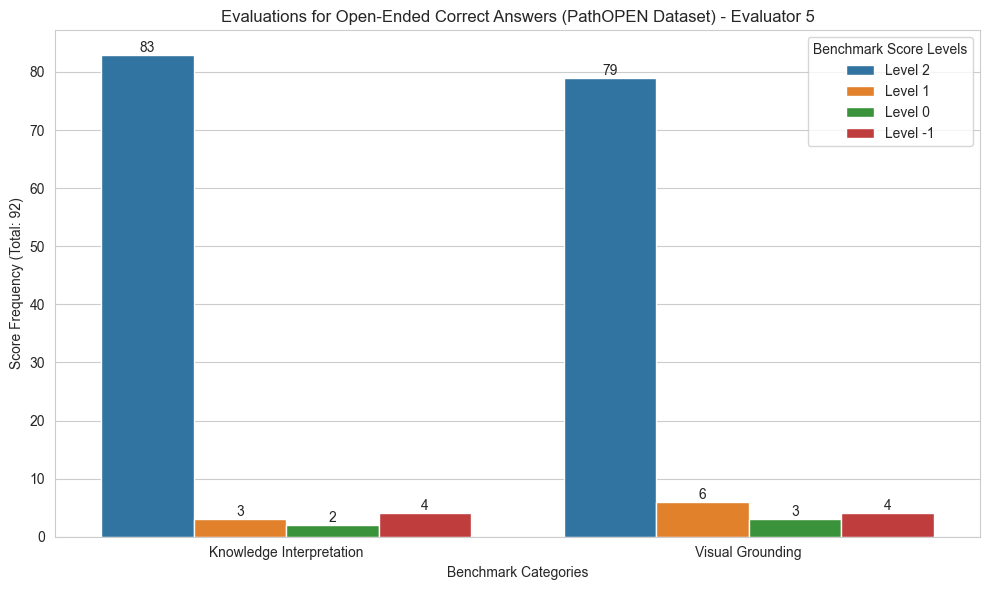

In [118]:
temp_data = correct_answer_eval_data.loc['Open-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
plt.title(f'Evaluations for Open-Ended Correct Answers (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answer_total[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_correct_answers.png')
plt.show()


MCQ Correct Answers Graph

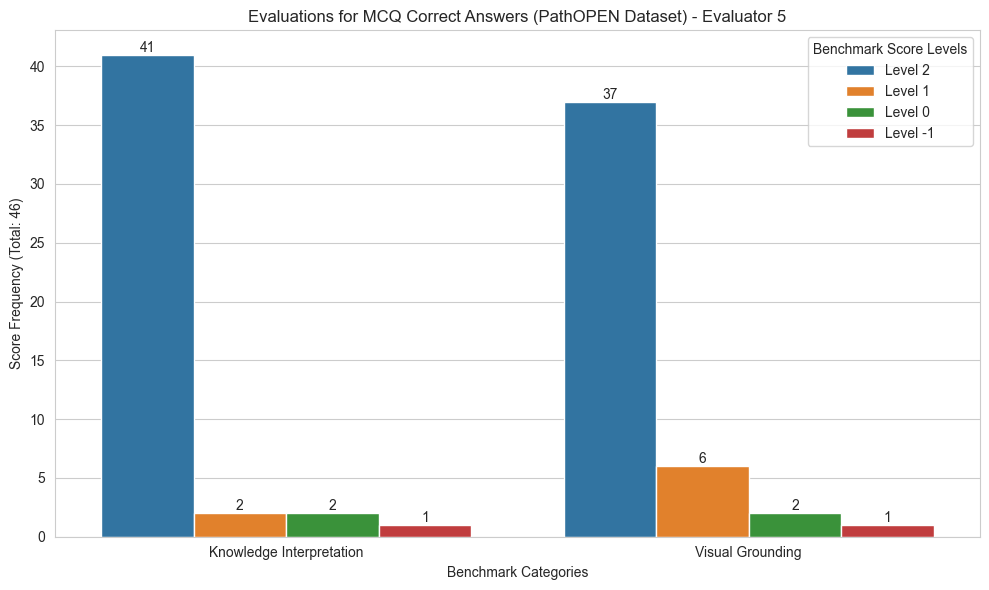

In [119]:
temp_data = correct_answer_eval_data.loc['MCQ'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)

plt.title(f'Evaluations for MCQ Correct Answers (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')

plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answer_total[2]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_correct_answers.png')
plt.show()

Close-Ended Correct Answers Graph

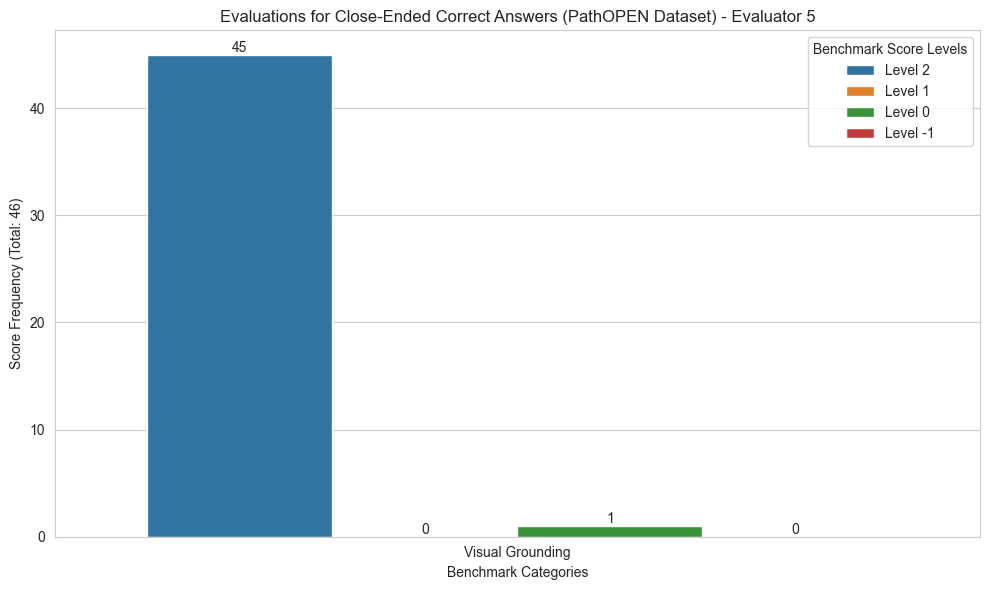

In [120]:
temp_data = correct_answer_eval_data.loc['Close-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
    
plt.title(f'Evaluations for Close-Ended Correct Answers (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answer_total[2]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_close_ended_correct_answers.png')
plt.show()

#### Wrong Answer

1

In [121]:
oe_wrong_answer_1_err_prox_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Wrong_Answer_1'].notnull() & eval_data['OE_Wrong_Answer_1_Err_Prox'].notnull()]
oe_wrong_answer_1_err_prox_total = len(oe_wrong_answer_1_err_prox_df)
oe_wrong_answer_1_err_prox_eval_2 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == 2])
oe_wrong_answer_1_err_prox_eval_1 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == 1])
oe_wrong_answer_1_err_prox_eval_0 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == 0])
oe_wrong_answer_1_err_prox_eval_neg_1 = len(oe_wrong_answer_1_err_prox_df[oe_wrong_answer_1_err_prox_df['OE_Wrong_Answer_1_Err_Prox'] == -1])

In [122]:
oe_wrong_answer_1_vis_ground_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Wrong_Answer_1'].notnull() & eval_data['OE_Wrong_Answer_1_Vis_Ground'].notnull()]
oe_wrong_answer_1_vis_ground_total = len(oe_wrong_answer_1_vis_ground_df)
oe_wrong_answer_1_vis_ground_eval_2 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == 2])
oe_wrong_answer_1_vis_ground_eval_1 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == 1])
oe_wrong_answer_1_vis_ground_eval_0 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == 0])
oe_wrong_answer_1_vis_ground_eval_neg_1 = len(oe_wrong_answer_1_vis_ground_df[oe_wrong_answer_1_vis_ground_df['OE_Wrong_Answer_1_Vis_Ground'] == -1])

2

In [123]:
oe_wrong_answer_2_err_prox_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Wrong_Answer_2'].notnull() & eval_data['OE_Wrong_Answer_2_Err_Prox'].notnull()]
oe_wrong_answer_2_err_prox_total = len(oe_wrong_answer_2_err_prox_df)
oe_wrong_answer_2_err_prox_eval_2 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == 2])
oe_wrong_answer_2_err_prox_eval_1 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == 1])
oe_wrong_answer_2_err_prox_eval_0 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == 0])
oe_wrong_answer_2_err_prox_eval_neg_1 = len(oe_wrong_answer_2_err_prox_df[oe_wrong_answer_2_err_prox_df['OE_Wrong_Answer_2_Err_Prox'] == -1])

In [124]:
oe_wrong_answer_2_vis_ground_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Wrong_Answer_2'].notnull() & eval_data['OE_Wrong_Answer_2_Vis_Ground'].notnull()]
oe_wrong_answer_2_vis_ground_total = len(oe_wrong_answer_2_vis_ground_df)
oe_wrong_answer_2_vis_ground_eval_2 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == 2])
oe_wrong_answer_2_vis_ground_eval_1 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == 1])
oe_wrong_answer_2_vis_ground_eval_0 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == 0])
oe_wrong_answer_2_vis_ground_eval_neg_1 = len(oe_wrong_answer_2_vis_ground_df[oe_wrong_answer_2_vis_ground_df['OE_Wrong_Answer_2_Vis_Ground'] == -1])

MCQ

In [125]:
mcq_wrong_answer_1_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1_Err_Prox'].notnull()]
mcq_wrong_answer_1_err_prox_total = len(mcq_wrong_answer_1_err_prox_df)
mcq_wrong_answer_1_err_prox_eval_2 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == 2])
mcq_wrong_answer_1_err_prox_eval_1 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == 1])
mcq_wrong_answer_1_err_prox_eval_0 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == 0])
mcq_wrong_answer_1_err_prox_eval_neg_1 = len(mcq_wrong_answer_1_err_prox_df[mcq_wrong_answer_1_err_prox_df['MCQ_OE_Wrong_Answer_1_Err_Prox'] == -1])

In [126]:
mcq_wrong_answer_1_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1'].notnull() & eval_data['MCQ_OE_Wrong_Answer_1_Vis_Ground'].notnull()]
mcq_wrong_answer_1_vis_ground_total = len(mcq_wrong_answer_1_vis_ground_df)
mcq_wrong_answer_1_vis_ground_eval_2 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == 2])
mcq_wrong_answer_1_vis_ground_eval_1 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == 1])
mcq_wrong_answer_1_vis_ground_eval_0 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == 0])
mcq_wrong_answer_1_vis_ground_eval_neg_1 = len(mcq_wrong_answer_1_vis_ground_df[mcq_wrong_answer_1_vis_ground_df['MCQ_OE_Wrong_Answer_1_Vis_Ground'] == -1])

In [127]:
mcq_wrong_answer_2_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2_Err_Prox'].notnull()]
mcq_wrong_answer_2_err_prox_total = len(mcq_wrong_answer_2_err_prox_df)
mcq_wrong_answer_2_err_prox_eval_2 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == 2])
mcq_wrong_answer_2_err_prox_eval_1 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == 1])
mcq_wrong_answer_2_err_prox_eval_0 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == 0])
mcq_wrong_answer_2_err_prox_eval_neg_1 = len(mcq_wrong_answer_2_err_prox_df[mcq_wrong_answer_2_err_prox_df['MCQ_OE_Wrong_Answer_2_Err_Prox'] == -1])

In [128]:
mcq_wrong_answer_2_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2'].notnull() & eval_data['MCQ_OE_Wrong_Answer_2_Vis_Ground'].notnull()]
mcq_wrong_answer_2_vis_ground_total = len(mcq_wrong_answer_2_vis_ground_df)
mcq_wrong_answer_2_vis_ground_eval_2 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == 2])
mcq_wrong_answer_2_vis_ground_eval_1 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == 1])
mcq_wrong_answer_2_vis_ground_eval_0 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == 0])
mcq_wrong_answer_2_vis_ground_eval_neg_1 = len(mcq_wrong_answer_2_vis_ground_df[mcq_wrong_answer_2_vis_ground_df['MCQ_OE_Wrong_Answer_2_Vis_Ground'] == -1])

In [129]:
mcq_wrong_answer_3_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3_Err_Prox'].notnull()]
mcq_wrong_answer_3_err_prox_total = len(mcq_wrong_answer_3_err_prox_df)
mcq_wrong_answer_3_err_prox_eval_2 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == 2])
mcq_wrong_answer_3_err_prox_eval_1 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == 1])
mcq_wrong_answer_3_err_prox_eval_0 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == 0])
mcq_wrong_answer_3_err_prox_eval_neg_1 = len(mcq_wrong_answer_3_err_prox_df[mcq_wrong_answer_3_err_prox_df['MCQ_OE_Wrong_Answer_3_Err_Prox'] == -1])

In [130]:
mcq_wrong_answer_3_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3'].notnull() & eval_data['MCQ_OE_Wrong_Answer_3_Vis_Ground'].notnull()]
mcq_wrong_answer_3_vis_ground_total = len(mcq_wrong_answer_3_vis_ground_df)
mcq_wrong_answer_3_vis_ground_eval_2 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == 2])
mcq_wrong_answer_3_vis_ground_eval_1 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == 1])
mcq_wrong_answer_3_vis_ground_eval_0 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == 0])
mcq_wrong_answer_3_vis_ground_eval_neg_1 = len(mcq_wrong_answer_3_vis_ground_df[mcq_wrong_answer_3_vis_ground_df['MCQ_OE_Wrong_Answer_3_Vis_Ground'] == -1])

In [131]:
mcq_wrong_answer_4_err_prox_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4_Err_Prox'].notnull()]
mcq_wrong_answer_4_err_prox_total = len(mcq_wrong_answer_4_err_prox_df)
mcq_wrong_answer_4_err_prox_eval_2 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == 2])
mcq_wrong_answer_4_err_prox_eval_1 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == 1])
mcq_wrong_answer_4_err_prox_eval_0 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == 0])
mcq_wrong_answer_4_err_prox_eval_neg_1 = len(mcq_wrong_answer_4_err_prox_df[mcq_wrong_answer_4_err_prox_df['MCQ_OE_Wrong_Answer_4_Err_Prox'] == -1])

In [132]:
mcq_wrong_answer_4_vis_ground_df = eval_data[eval_data['MCQ_OE_Question'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4'].notnull() & eval_data['MCQ_OE_Wrong_Answer_4_Vis_Ground'].notnull()]
mcq_wrong_answer_4_vis_ground_total = len(mcq_wrong_answer_4_vis_ground_df)
mcq_wrong_answer_4_vis_ground_eval_2 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == 2])
mcq_wrong_answer_4_vis_ground_eval_1 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == 1])
mcq_wrong_answer_4_vis_ground_eval_0 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == 0])
mcq_wrong_answer_4_vis_ground_eval_neg_1 = len(mcq_wrong_answer_4_vis_ground_df[mcq_wrong_answer_4_vis_ground_df['MCQ_OE_Wrong_Answer_4_Vis_Ground'] == -1])

Calculating the consolidated information all the wrong questions/answers

In [133]:
wrong_answer_que_type = [
                            'Open-Ended',
                            'Open-Ended',
                            'MCQ',
                            'MCQ'
                        ]


wrong_answer_benchmark_label = [
                                    'Error Proximity',
                                    'Visual Grounding',
                                    'Error Proximity',
                                    'Visual Grounding'
                                ]

wrong_answer_total = [  oe_wrong_answer_1_err_prox_total + oe_wrong_answer_2_err_prox_total,
                        oe_wrong_answer_1_vis_ground_total + oe_wrong_answer_2_vis_ground_total,
                        mcq_wrong_answer_1_err_prox_total + mcq_wrong_answer_2_err_prox_total + mcq_wrong_answer_3_err_prox_total + mcq_wrong_answer_4_err_prox_total,
                        mcq_wrong_answer_1_vis_ground_total + mcq_wrong_answer_2_vis_ground_total + mcq_wrong_answer_3_vis_ground_total + mcq_wrong_answer_4_vis_ground_total
                    ]

wrong_answer_eval_2 = [  oe_wrong_answer_1_err_prox_eval_2 + oe_wrong_answer_2_err_prox_eval_2,
                        oe_wrong_answer_1_vis_ground_eval_2 + oe_wrong_answer_2_vis_ground_eval_2,
                        mcq_wrong_answer_1_err_prox_eval_2 + mcq_wrong_answer_2_err_prox_eval_2 + mcq_wrong_answer_3_err_prox_eval_2 + mcq_wrong_answer_4_err_prox_eval_2,
                        mcq_wrong_answer_1_vis_ground_eval_2 + mcq_wrong_answer_2_vis_ground_eval_2 + mcq_wrong_answer_3_vis_ground_eval_2 + mcq_wrong_answer_4_vis_ground_eval_2
                    ]

wrong_answer_eval_1 = [  oe_wrong_answer_1_err_prox_eval_1 + oe_wrong_answer_2_err_prox_eval_1,
                        oe_wrong_answer_1_vis_ground_eval_1 + oe_wrong_answer_2_vis_ground_eval_1,
                        mcq_wrong_answer_1_err_prox_eval_1 + mcq_wrong_answer_2_err_prox_eval_1 + mcq_wrong_answer_3_err_prox_eval_1 + mcq_wrong_answer_4_err_prox_eval_1,
                        mcq_wrong_answer_1_vis_ground_eval_1 + mcq_wrong_answer_2_vis_ground_eval_1 + mcq_wrong_answer_3_vis_ground_eval_1 + mcq_wrong_answer_4_vis_ground_eval_1
                    ]

wrong_answer_eval_0 = [  oe_wrong_answer_1_err_prox_eval_0 + oe_wrong_answer_2_err_prox_eval_0,
                        oe_wrong_answer_1_vis_ground_eval_0 + oe_wrong_answer_2_vis_ground_eval_0,
                        mcq_wrong_answer_1_err_prox_eval_0 + mcq_wrong_answer_2_err_prox_eval_0 + mcq_wrong_answer_3_err_prox_eval_0 + mcq_wrong_answer_4_err_prox_eval_0,
                        mcq_wrong_answer_1_vis_ground_eval_0 + mcq_wrong_answer_2_vis_ground_eval_0 + mcq_wrong_answer_3_vis_ground_eval_0 + mcq_wrong_answer_4_vis_ground_eval_0
                    ]

wrong_answer_eval_neg_1 = [  oe_wrong_answer_1_err_prox_eval_neg_1 + oe_wrong_answer_2_err_prox_eval_neg_1,
                            oe_wrong_answer_1_vis_ground_eval_neg_1 + oe_wrong_answer_2_vis_ground_eval_neg_1,
                            mcq_wrong_answer_1_err_prox_eval_neg_1 + mcq_wrong_answer_2_err_prox_eval_neg_1 + mcq_wrong_answer_3_err_prox_eval_neg_1 + mcq_wrong_answer_4_err_prox_eval_neg_1,
                            mcq_wrong_answer_1_vis_ground_eval_neg_1 + mcq_wrong_answer_2_vis_ground_eval_neg_1 + mcq_wrong_answer_3_vis_ground_eval_neg_1 + mcq_wrong_answer_4_vis_ground_eval_neg_1
                        ]

wrong_answer_eval_data = pd.DataFrame({'Level 2': wrong_answer_eval_2,
                                        'Level 1': wrong_answer_eval_1,
                                        'Level 0': wrong_answer_eval_0,
                                        'Level -1': wrong_answer_eval_neg_1}, index=[wrong_answer_que_type, wrong_answer_benchmark_label])

wrong_answer_eval_data

Level 2  Level 1  Level 0  Level -1
Open-Ended Error Proximity         5       12       52         6
           Visual Grounding        3       17       49         6
MCQ        Error Proximity        10       18      155         1
           Visual Grounding        7       18      157         2

Save the Evaluation Data for correct answers

In [134]:
wrong_answer_eval_data.to_pickle(os.path.join(output_data_path, 'pathopen_wrong_answer_eval_data.pkl'))

Open-Ended Wrong Answers Graph

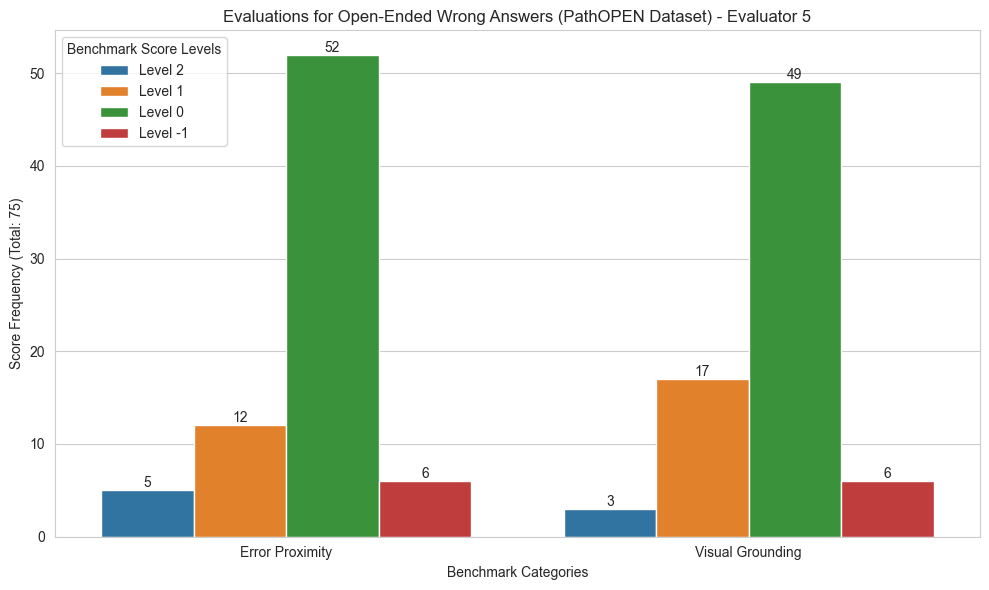

In [135]:
temp_data = wrong_answer_eval_data.loc['Open-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
    
plt.title(f'Evaluations for Open-Ended Wrong Answers (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {wrong_answer_total[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_wrong_answers.png')
plt.show()

MCQ Wrong Answers Graph

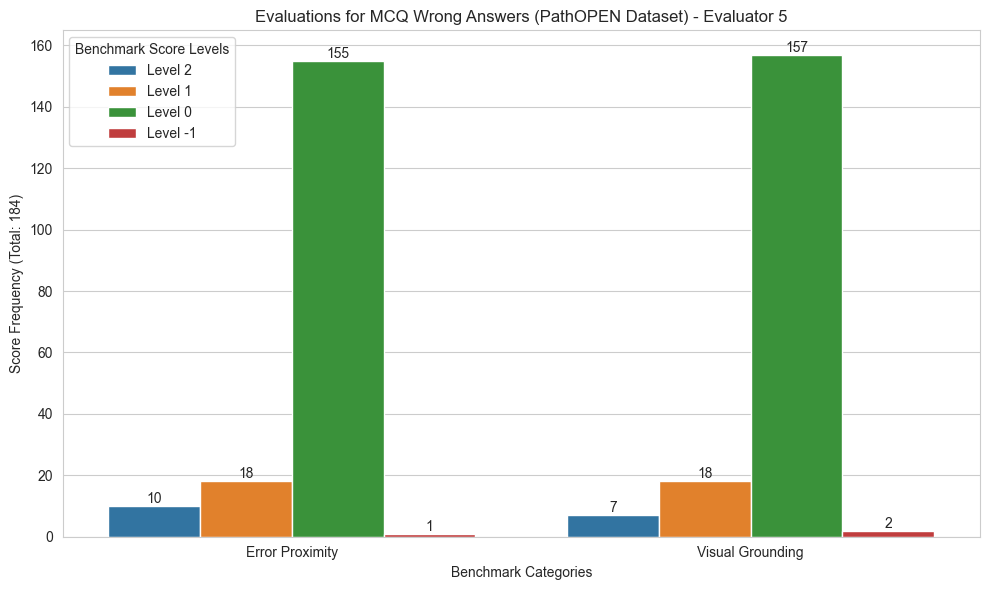

In [136]:
temp_data = wrong_answer_eval_data.loc['MCQ'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)

plt.title(f'Evaluations for MCQ Wrong Answers (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {wrong_answer_total[2]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_wrong_answers.png')
plt.show()